# Projeto: Bank Marketing (UCI Machine Learning Repository)

Estes dados estão relacionados a campanhas de marketing, baseadas em ligações telefônicas, de uma instituição bancária portuguesa.

As campanhas de marketing foram realizadas por meio de chamadas telefônicas. Frequentemente, foram necessários mais de um contato com o mesmo cliente para avaliar se o produto (depósito a prazo bancário) vai ser obtido ou não.

## 2. Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(pd.__version__)

3.0.4


### 2.1 Lendo os dados da campanha de marketing

In [2]:
df = pd.read_csv('../data/bank-full.csv', sep= ';', encoding='utf-8')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [5]:
df.shape

(45211, 17)

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

## 3. Qual a distribuição da idade dos clientes no dataset?

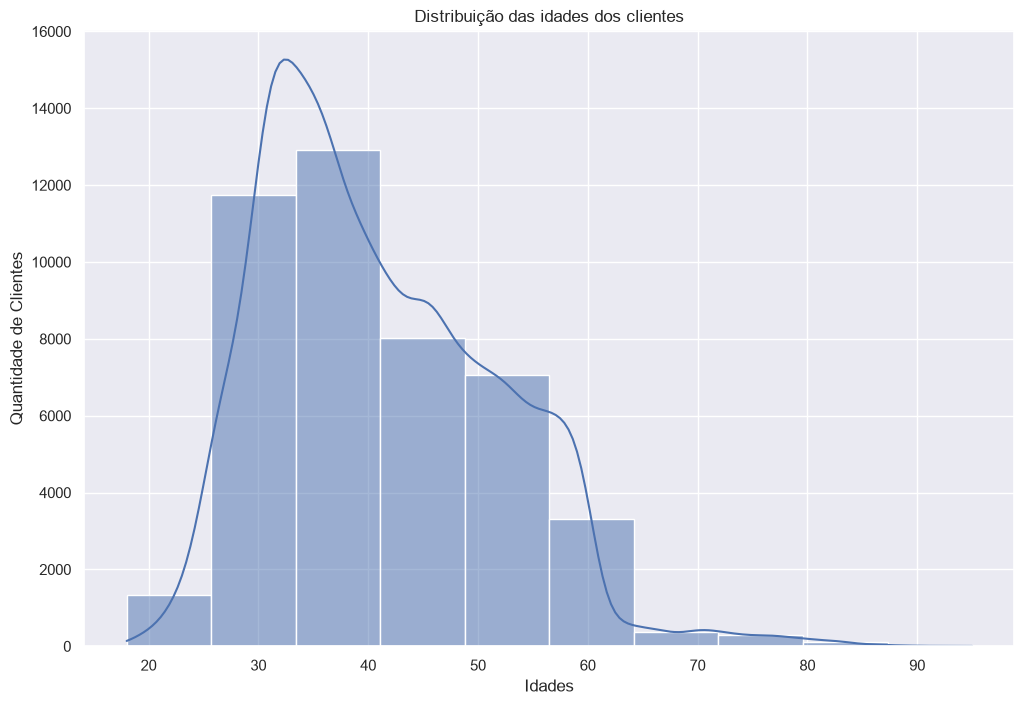

In [7]:
plt.figure(figsize=(12,8))

sns.set_theme(style='darkgrid')

sns.histplot(
    data=df,
    x='age',
    bins=10,
    kde=True
)

plt.title('Distribuição das idades dos clientes')
plt.xlabel('Idades')
plt.ylabel('Quantidade de Clientes')
plt.show()

A distribuição das idades não segue um padrão simétrico, apresentando assimetria à direita, com predominância de clientes entre 30 e 40 anos e redução gradual da frequência nas idades mais elevadas. A presença de uma cauda longa indica que existem poucos clientes idosos, enquanto a maior parte da população concentra-se em uma faixa etária entre 30 e 50 anos. Esse comportamento é típico de bases de clientes compostas predominantemente por adultos em idade economicamente ativa e deve ser considerado em análises estatísticas e na definição de estratégias de negócio.

## 4. Qual é a distribuição das profissões? E qual é a profissão mais comum entre os clientes?

In [8]:
# Contagem das profissões
contagem_job = df['job'].value_counts().reset_index()

# Renomear as colunas
contagem_job.columns = ['Profissão', 'Quantidade']

contagem_job

,Profissão,Quantidade
0,blue-collar,9732
1,management,9458
2,technician,7597
3,admin.,5171
4,services,4154
5,retired,2264
6,self-employed,1579
7,entrepreneur,1487
8,unemployed,1303
9,housemaid,1240


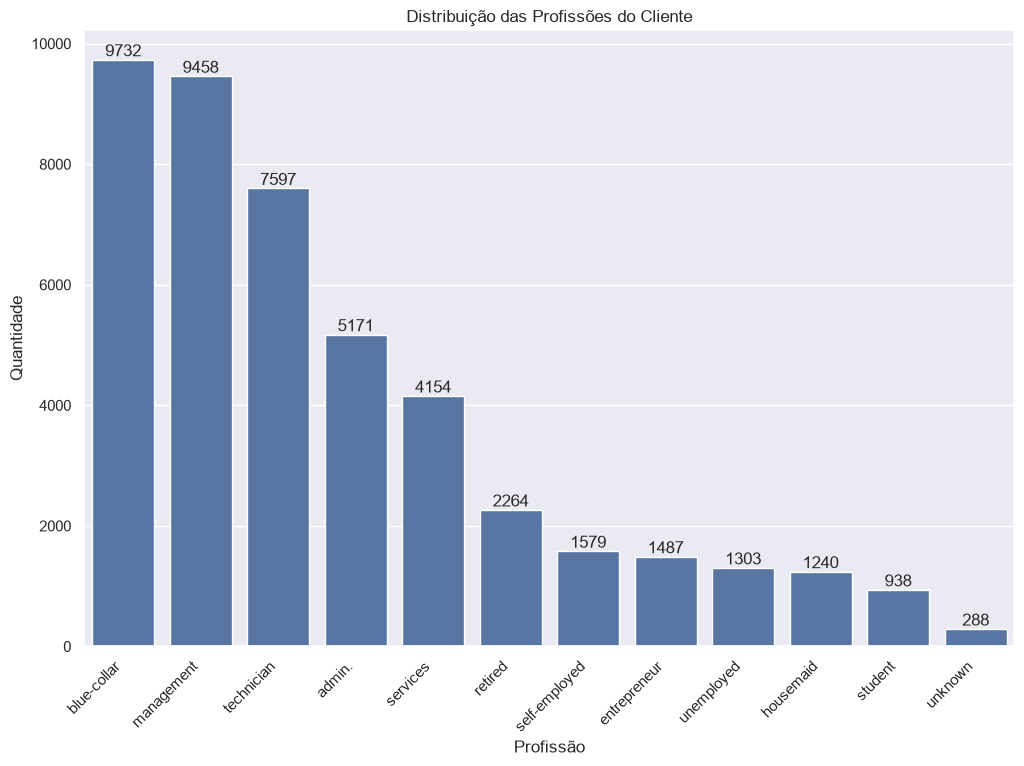

In [9]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=contagem_job,
    x='Profissão',
    y='Quantidade'
)

# Adicionar os rótulos
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribuição das Profissões do Cliente')
plt.xlabel('Profissão')
plt.ylabel('Quantidade')
plt.xticks(rotation=45, ha='right')
plt.show()

A análise da distribuição das profissões mostra que operários (blue-collar) representam o maior grupo de clientes da instituição financeira. No entanto, observa-se que a quantidade de clientes da categoria gerentes (management) é bastante próxima, indicando que ambos os segmentos possuem elevada representatividade na carteira.

Sob a perspectiva de negócio, esse resultado sugere que estratégias comerciais, campanhas de marketing e o desenvolvimento de produtos devem considerar esses dois perfis como públicos prioritários. Embora os operários constituam a maior parcela da base de clientes, a forte presença de gerentes indica uma oportunidade para a oferta de produtos e serviços diferenciados, alinhados às características e necessidades de cada segmento, contribuindo para aumentar a efetividade das ações comerciais e a rentabilidade da carteira.

## 5. Quais são as principais formas de contato utilizadas pela instituição financeira?

In [10]:
# Contagem das formas de contato
contagem_formas_contato = df['contact'].value_counts()

contagem_formas_contato

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

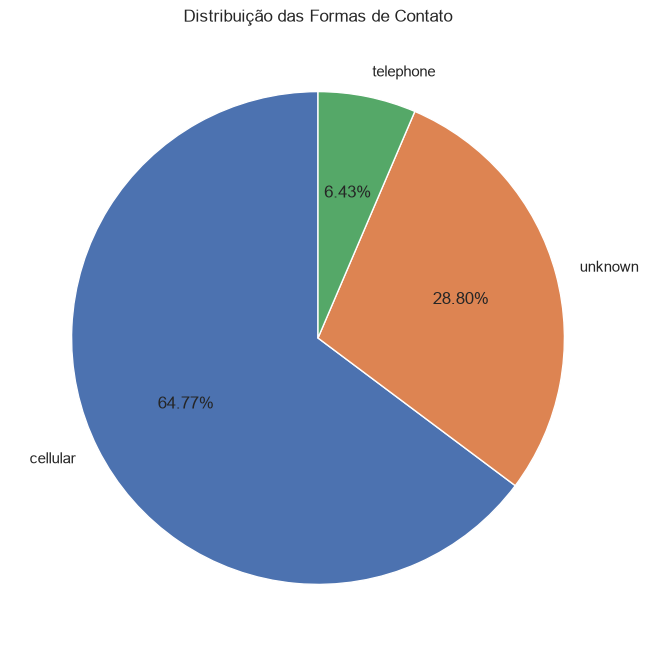

In [11]:
# Gráfico de pizza
plt.figure(figsize=(12,8))

plt.pie(
    contagem_formas_contato,
    labels=contagem_formas_contato.index,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('Distribuição das Formas de Contato')
plt.show()

A análise dos canais de contato revela que o **celular (cellular)** é, de forma significativa, o principal meio de comunicação utilizado entre o banco e seus clientes. Em segundo lugar aparece a categoria **unknown**, que representa contatos cuja origem ou canal não foi devidamente identificado, seguida pelo canal **telefone (telephone)**, com menor participação.

Do ponto de vista estratégico, esse resultado evidencia a crescente relevância dos dispositivos móveis como principal ponto de interação com os clientes, reforçando a importância de investimentos em campanhas, comunicações e experiências digitais otimizadas para esse canal. Além disso, a elevada participação da categoria **unknown** merece atenção, pois pode indicar falhas no registro ou na qualidade dos dados, limitando a capacidade da instituição de compreender plenamente a efetividade de seus canais de comunicação. Melhorias nos processos de captura e governança de dados podem contribuir para decisões mais assertivas sobre alocação de recursos e estratégias de relacionamento.

Em resumo, os dados sugerem que o celular deve permanecer como canal prioritário nas ações de comunicação e relacionamento, ao mesmo tempo em que destacam uma oportunidade de aprimoramento na qualidade das informações relacionadas aos canais de contato.

## 6. Existe alguma relação entre o saldo do cliente (*balance*) e a idade?

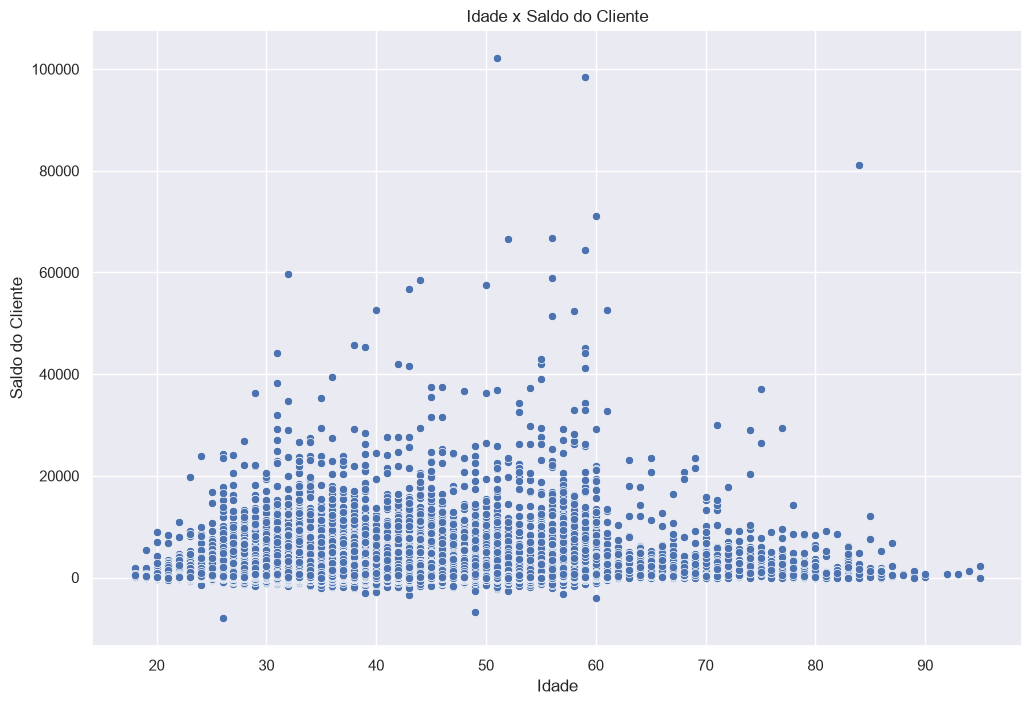

In [12]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='age',
    y='balance'
)

plt.title('Idade x Saldo do Cliente')
plt.xlabel('Idade')
plt.ylabel('Saldo do Cliente')

plt.show()

O gráfico indica que não existe uma correlação visual forte entre idade e saldo bancário. Embora clientes de meia-idade concentrem os maiores saldos e a maior variabilidade financeira, o comportamento do saldo permanece bastante heterogêneo em todas as faixas etárias. Esses resultados sugerem que o saldo bancário é influenciado por múltiplos fatores além da idade, reforçando a necessidade de análises multivariadas para apoiar estratégias de segmentação, marketing e concessão de produtos financeiros.

## 7. Verificar se o saldo bancário possui alguma relação com inadimplência, possuir casa ou possuir empréstimo.

In [13]:
saldo_bancario_habitacao = pd.pivot_table(
    df,
    index='housing',
    values='balance',
    aggfunc='mean',
    fill_value=0
)

saldo_bancario_habitacao

,balance
housing,
no,1596.501270
yes,1175.103064


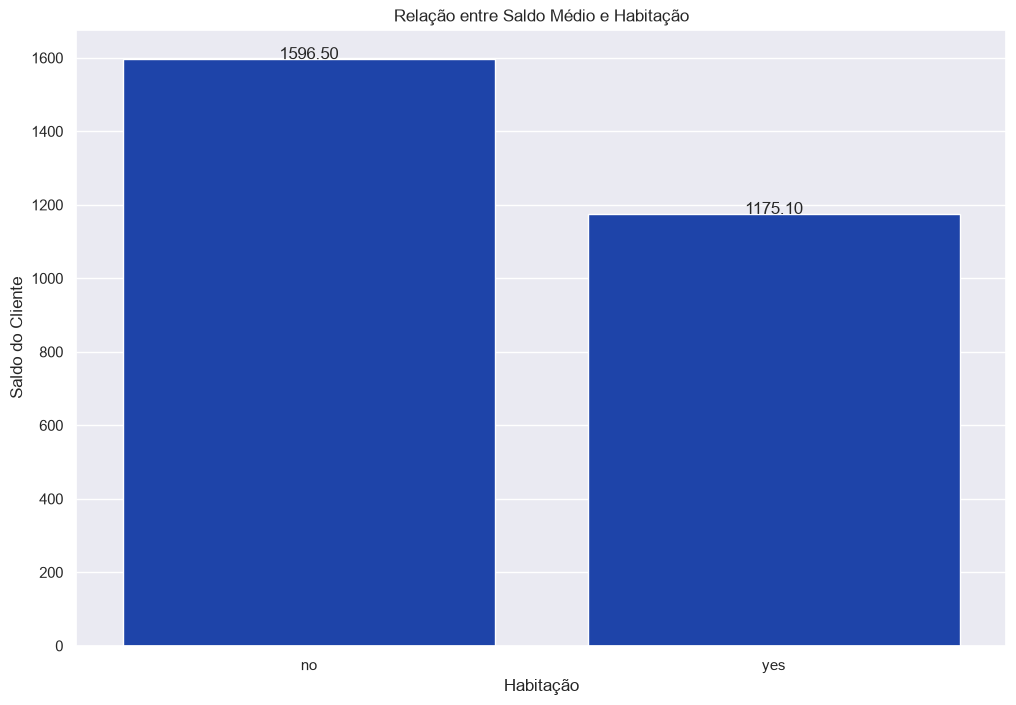

In [14]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=saldo_bancario_habitacao,
    x='housing',
    y='balance',
    color="#0739C0"
)

# Adicionar os rótulos
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center'
    )

plt.title('Relação entre Saldo Médio e Habitação')
plt.xlabel('Habitação')
plt.ylabel('Saldo do Cliente')

plt.show()

O gráfico revela que clientes **sem habitação** possuem, em média, um saldo bancário **significativamente maior** (1.596,50) do que clientes **com habitação** (1.175,10).

Isso sugere que o comprometimento financeiro decorrente de um financiamento/empréstimo habitacional pode estar associado a uma menor capacidade de acúmulo de saldo em conta, enquanto clientes sem essa obrigação tendem a manter reservas mais elevadas.

É importante destacar que essa é uma relação **correlacional**, não causal — outros fatores (renda, idade, perfil financeiro) podem influenciar esse padrão e mereceriam investigação adicional antes de qualquer decisão estratégica baseada apenas nessa variável.

In [15]:
saldo_bancario_emprestimo = pd.pivot_table(
    df,
    index='loan',
    values='balance',
    aggfunc='mean',
    fill_value=0
)

saldo_bancario_emprestimo

,balance
loan,
no,1474.453631
yes,774.309912


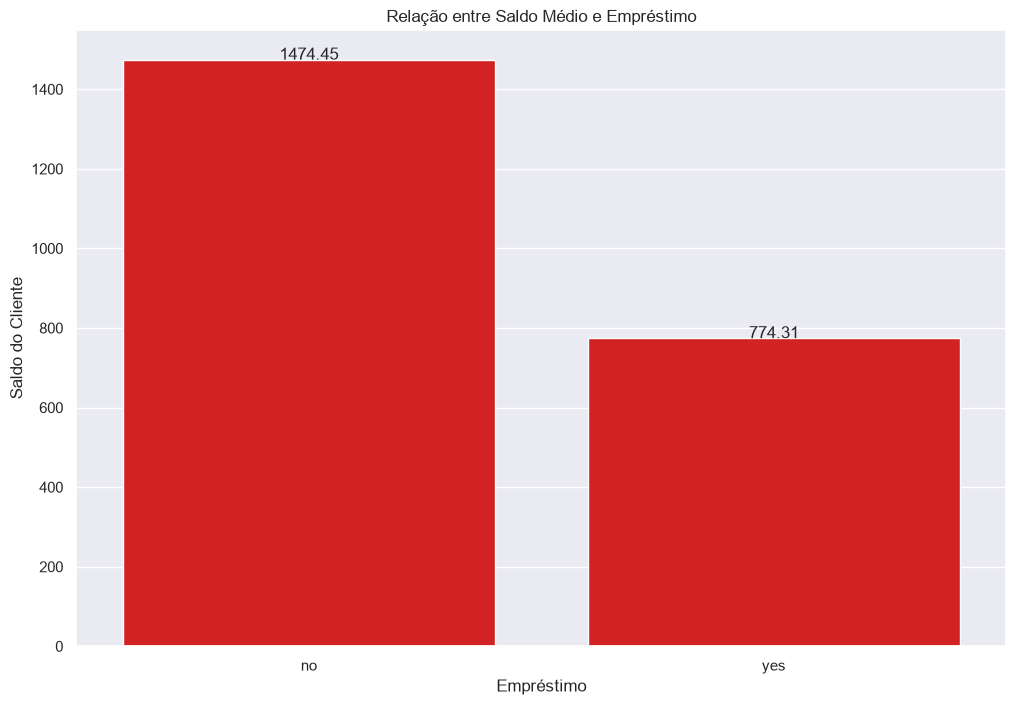

In [16]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=saldo_bancario_emprestimo,
    x='loan',
    y='balance',
    color="#EE0606"
)

# Adicionar os rótulos
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center'
    )

plt.title('Relação entre Saldo Médio e Empréstimo')
plt.xlabel('Empréstimo')
plt.ylabel('Saldo do Cliente')

plt.show()

Clientes com empréstimo pessoal apresentam saldo médio significativamente menor do que aqueles sem esse compromisso — uma diferença de aproximadamente $ 700, a maior entre as comparações feitas até o momento. Isso reforça a hipótese de que obrigações financeiras recorrentes (empréstimos e financiamentos) impactam diretamente a capacidade de acumulação de saldo dos clientes, sendo o empréstimo pessoal a variável com efeito mais expressivo até aqui. Recomenda-se investigar essa relação de forma multivariada (considerando renda, idade e outras obrigações simultaneamente) para confirmar se o efeito se mantém isolado ou se é resultado de fatores correlacionados.

In [17]:
saldo_bancario_inadimplencia = pd.pivot_table(
    df,
    index='default',
    values='balance',
    aggfunc='mean',
    fill_value=0
)

saldo_bancario_inadimplencia

,balance
default,
no,1389.806424
yes,-137.624540


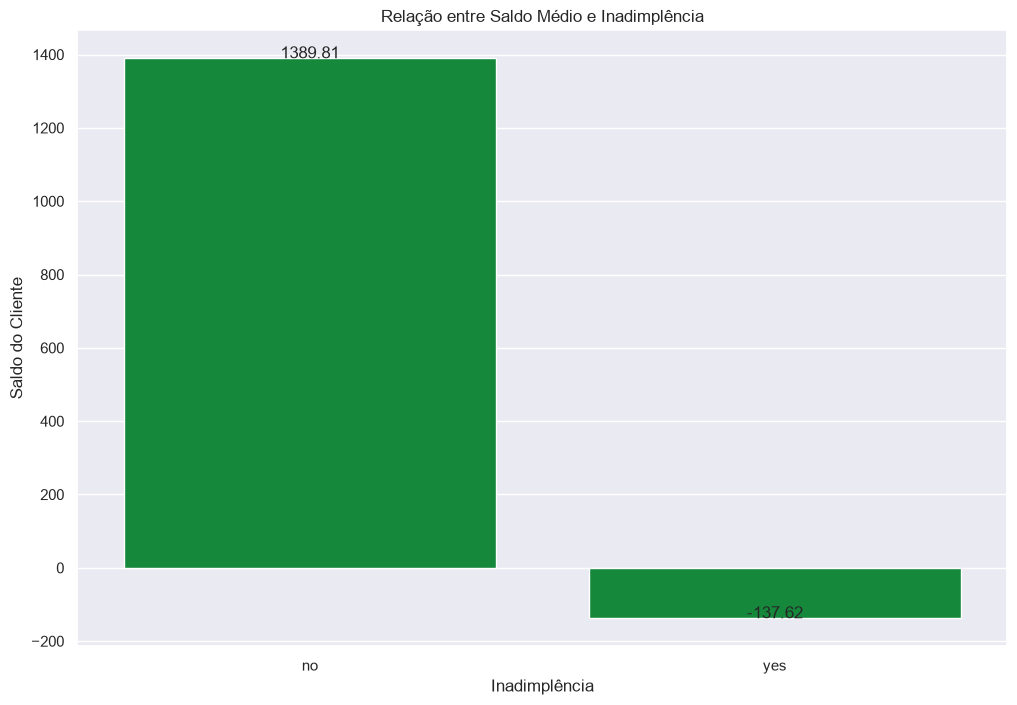

In [18]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=saldo_bancario_inadimplencia,
    x='default',
    y='balance',
    color="#039B36"
)

# Adicionar os rótulos
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center'
    )

plt.title('Relação entre Saldo Médio e Inadimplência')
plt.xlabel('Inadimplência')
plt.ylabel('Saldo do Cliente')

plt.show()

A inadimplência é a variável com impacto mais severo sobre o saldo médio entre todas as analisadas até agora, sendo a única a apresentar saldo médio negativo no grupo afetado. Isso indica que clientes inadimplentes não apenas têm saldo reduzido, mas efetivamente estão endividados junto ao banco, em contraste com clientes adimplentes que mantêm reservas financeiras saudáveis (saldo médio de $ 1.389,81). Esse padrão reforça a inadimplência como um forte indicador de vulnerabilidade financeira, sendo uma variável estrategicamente relevante para modelos de risco de crédito e políticas de cobrança/prevenção.

## 6.1 A proporção de clientes que adquiriram o depósito a prazo do banco é a mesma entre outliers quando comparadas com os não-outliers na variável *balance*.

In [19]:
# Identificar os outliers pelo método IQR

Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')

Limite inferior: -1962.0
Limite superior: 3462.0


In [20]:
# Definir a variável categórica outlier
df['is_outlier'] = (df['balance'] < limite_inferior) | (df['balance'] > limite_superior)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,is_outlier
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,False
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,False
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,False
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,False
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,False


In [21]:
# Quantidade de outliers e não-outliers

print(f'Total de outliers: {df['is_outlier'].sum()}')
print(f'Total de não-outliers: {(~df['is_outlier']).sum()}')

Total de outliers: 4729
Total de não-outliers: 40482


In [22]:
# Separar em grupos

grupo_outlier = df[df['is_outlier']]
grupo_nao_outlier = df[~df['is_outlier']]

In [23]:
# Proporção de adesão em cada grupo

proporcoes = (
    df.groupby('is_outlier')['y']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .reset_index()
)

proporcoes = proporcoes.rename(columns={'y': 'proporcao'})

proporcoes

,is_outlier,proporcao
0,False,11.170397
1,True,16.219074


In [24]:
# Ajustar os rótulos do eixo X
proporcoes['is_outlier'] = proporcoes['is_outlier'].map({False:'No', True:'Yes'})

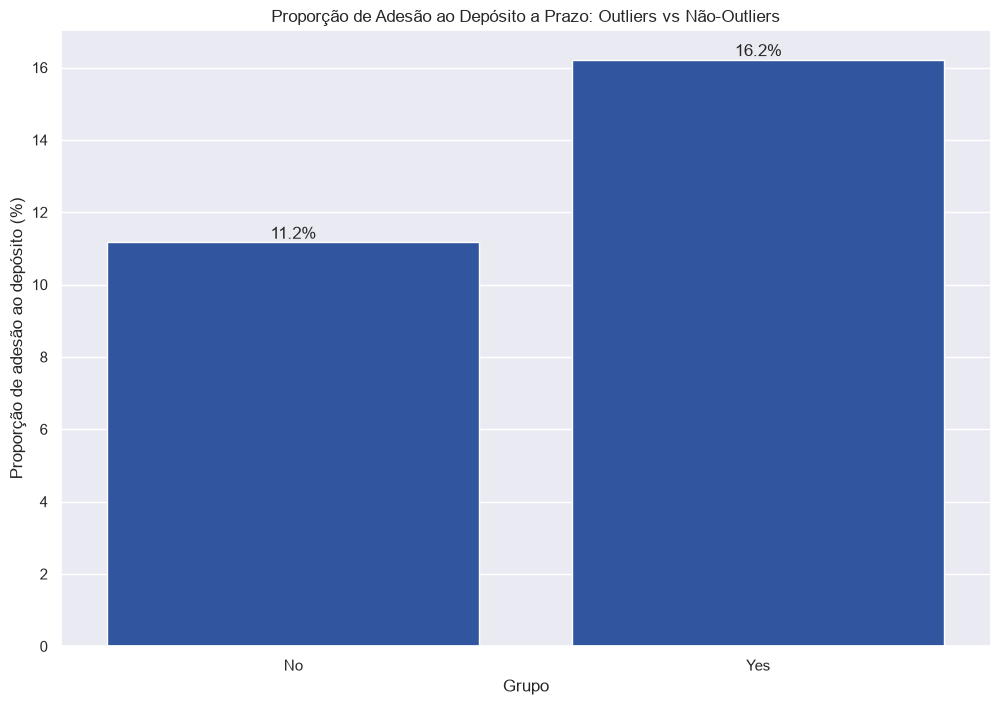

In [28]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=proporcoes,
    x='is_outlier',
    y='proporcao',
    color="#1f4fb0"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
    
plt.title('Proporção de Adesão ao Depósito a Prazo: Outliers vs Não-Outliers')
plt.xlabel('Grupo')
plt.ylabel('Proporção de adesão ao depósito (%)')

plt.show()

A análise comparou a taxa de adesão ao depósito a prazo entre clientes classificados como outliers de saldo e aqueles com saldos dentro da faixa considerada normal. Caso as diferenças sejam confirmadas, o banco pode considerar estratégias comerciais específicas para clientes com saldos extremos, desenvolvendo ofertas mais personalizadas e direcionando campanhas para segmentos com maior probabilidade de contratação do produto.

## 6.2 A média e a distribuição das idades dos outliers é parecida com as do não-outliers? E a média e distribuição do saldo?

In [37]:
# Comparar a média das idades
media_outliers = df.groupby('is_outlier')['age'].agg('mean').reset_index()

media_outliers['is_outlier'] = media_outliers['is_outlier'].map({False:'No', True:'Yes'})

media_outliers

,is_outlier,age
0,No,40.627686
1,Yes,43.577289


C:\Users\hccru\AppData\Local\Temp\ipykernel_12504\3451779641.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No', 'Yes'])


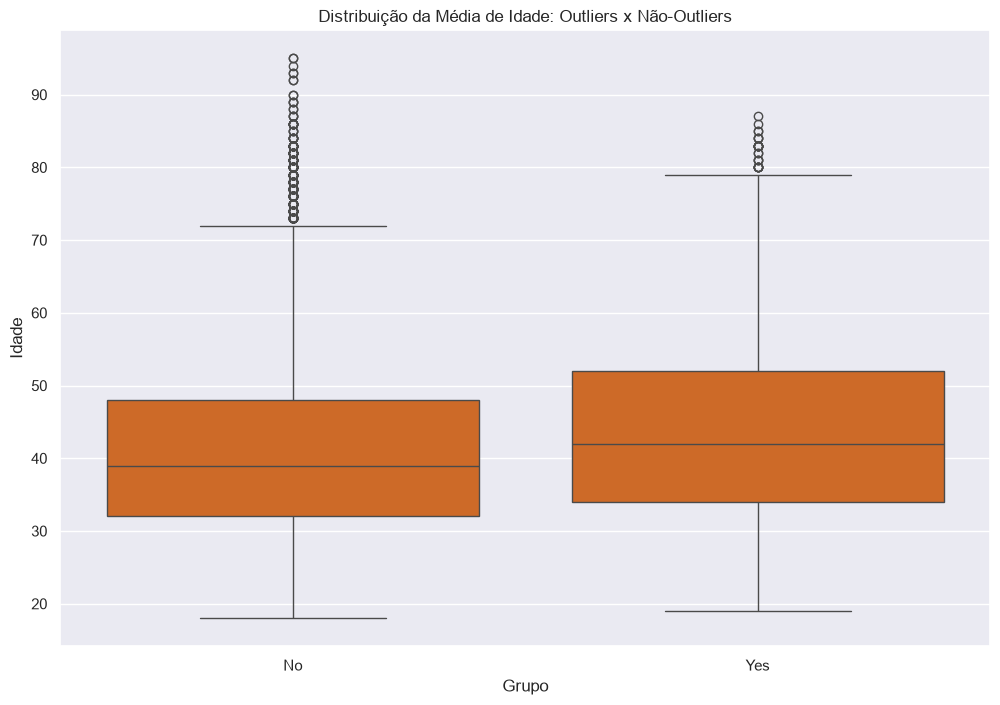

In [41]:
plt.figure(figsize=(12,8))

ax = sns.boxplot(
    data=df,
    x='is_outlier',
    y='age',
    color= "#e9640c"
)

ax.set_xticklabels(['No', 'Yes'])

plt.title('Distribuição da Média de Idade: Outliers x Não-Outliers')
plt.xlabel('Grupo')
plt.ylabel('Idade')

plt.show()


A comparação das idades indica que os clientes classificados como outliers apresentam idade média superior à dos não-outliers. A distribuição das idades também evidencia uma maior concentração de clientes em faixas etárias mais elevadas no grupo de outliers

In [42]:
# Comparar a média do saldo
media_saldo_outliers = df.groupby('is_outlier')['balance'].agg('mean').reset_index()

media_saldo_outliers

,is_outlier,balance
0,False,640.636233
1,True,7539.743286


C:\Users\hccru\AppData\Local\Temp\ipykernel_12504\1033290053.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No', 'Yes'])


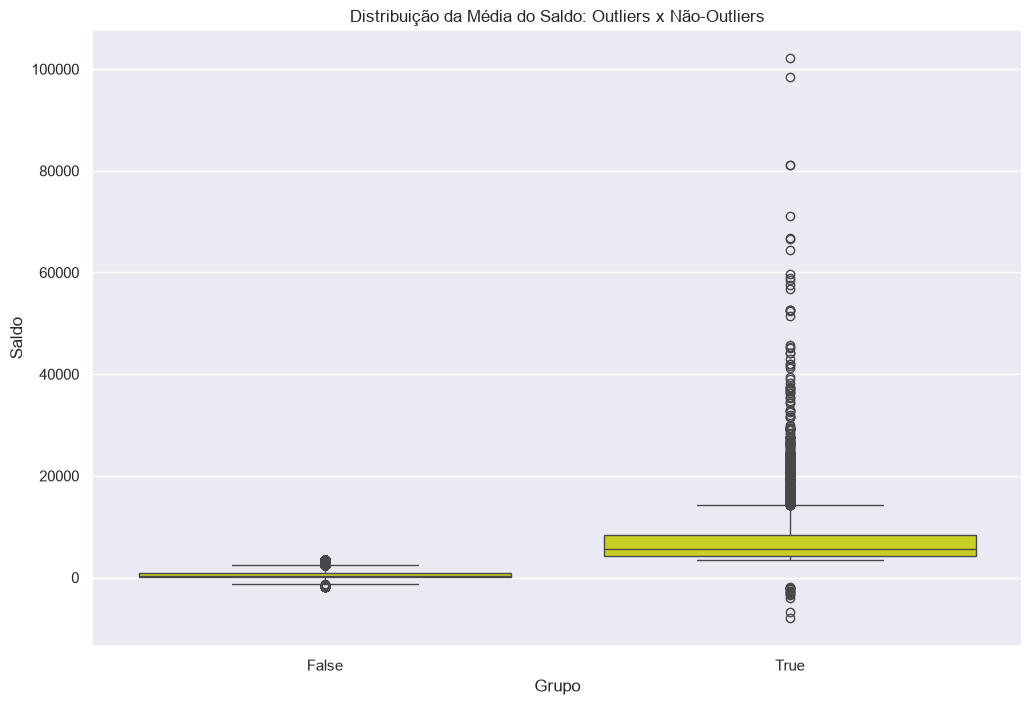

In [45]:
plt.figure(figsize=(12,8))

sns.boxplot(
    data=df,
    x='is_outlier',
    y='balance',
    color="#E5E908"
)

ax.set_xticklabels(['No', 'Yes'])

plt.title('Distribuição da Média do Saldo: Outliers x Não-Outliers')
plt.xlabel('Grupo')
plt.ylabel('Saldo')

plt.show()

Conforme esperado, os clientes classificados como outliers apresentam médias e dispersões de saldo significativamente superiores às observadas entre os não-outliers, uma vez que essa classificação foi construída com base na própria variável saldo. A análise evidencia que uma pequena parcela da carteira concentra valores financeiros muito elevados, indicando alta heterogeneidade entre os clientes e reforçando a importância de estratégias de segmentação específicas para esse grupo.